# Robustness Analysis — NIL Research Project

**ECC3479 | Data and Evidence in Economics | Elena Langridge, Teah Papageorgiou, Lily Proposch**  

This notebook performs dedicated robustness checks for the descriptive association between social media deal status and average NIL transaction value. The analysis is documented in markdown, and the estimation is performed in code.

**Purpose:** Stress-test the main descriptive finding from the primary econometric analysis.

### Restatement of the primary result
The preferred specification finds that, conditional on school, sport, and year, social media NIL deals are associated with roughly a 38% higher average transaction value.

### Grading declaration
- Declared claim: descriptive association, not causal.
- This notebook evaluates whether the conditional correlation remains stable across alternative controls, sample definitions, functional forms, and inference methods.

### Robustness checks included
1. Alternative control set: compare the preferred M4 specification with a year+school FE specification (M3).
2. Alternative sample: drop UC San Diego and winsorize the outcome at the 95th percentile.
3. Alternative functional form: estimate the same specification on raw average transaction values.
4. Alternative inference: compare school-clustered SEs to two-way school+sport clustered SEs.


## 1. Setup and data loading

Load the aggregated analysis dataset and prepare the key variables for the robustness checks.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from scipy import stats
from scipy.linalg import lstsq
import os
from pathlib import Path

data_path = Path('data/clean/nil_merged_analysis.csv')
possible_paths = [
    Path.cwd() / 'data' / 'clean' / 'nil_merged_analysis.csv',
    Path.cwd().parent / 'data' / 'clean' / 'nil_merged_analysis.csv',
    Path.cwd().parent.parent / 'data' / 'clean' / 'nil_merged_analysis.csv',
]
data_path = next((p for p in possible_paths if p.exists()), None)
if data_path is None:
    data_path = Path('..') / 'data' / 'clean' / 'nil_merged_analysis.csv'
df = pd.read_csv(data_path)
df = df[df['year'] <= 2024].copy()
df['log_value'] = np.log1p(df['avg_transaction_value'])
df['year_str'] = df['year'].astype(str)
df['school_str'] = df['school'].astype(str)
df['sport_str'] = df['sport'].astype(str)

print(f'Loaded {len(df)} rows from {data_path}')
print(df[['school', 'sport', 'year', 'is_social_media', 'avg_transaction_value']].head())

Loaded 361 rows from /Users/elenalangridge/Desktop/University 2026 /ECC3479 - Data and Evidence in Economics /Project /Data + GitHub repo/nil-research-project/data/clean/nil_merged_analysis.csv
         school       sport  year  is_social_media  avg_transaction_value
0    calpolyslo    Football  2024                0            2000.000000
1  csulongbeach  Basketball  2022                0            1000.000000
2  csulongbeach  Basketball  2022                1             360.000000
3  csulongbeach  Basketball  2023                1             243.090909
4  csulongbeach  Basketball  2024                0             642.857143


## 2. Regression helper functions

Define OLS estimation with HC3 robust standard errors and cluster adjustment functions.

In [2]:
def dummify(df, cols, drop_first=True):
    parts, labels = [], []
    for c in cols:
        values = sorted(df[c].unique())
        if drop_first:
            values = values[1:]
        for val in values:
            parts.append((df[c] == val).astype(float).values)
            labels.append(f'{c}[{val}]')
    if parts:
        return np.column_stack(parts), labels
    return np.zeros((len(df), 0)), labels

def ols_hc3(X, y, labels):
    n, k = X.shape
    beta, _, _, _ = lstsq(X, y)
    resid = y - X.dot(beta)
    XtXinv = np.linalg.pinv(X.T.dot(X))
    hat = np.diag(X.dot(XtXinv).dot(X.T))
    hat = np.clip(hat, 0, 0.9999)
    e_adj = resid / (1 - hat)
    meat = X.T.dot(np.diag(e_adj**2)).dot(X)
    vcov = XtXinv.dot(meat).dot(XtXinv)
    se = np.sqrt(np.abs(np.diag(vcov)))
    tstat = beta / se
    pval = 2 * (1 - stats.t.cdf(np.abs(tstat), df=n - k))
    r2 = 1 - np.sum(resid**2) / np.sum((y - y.mean())**2)
    return dict(beta=beta, se=se, pval=pval, r2=r2, n=n, labels=labels, resid=resid, X=X, XtXinv=XtXinv)

def clustered_se(r, group_arr):
    X, resid, XtXinv = r['X'], r['resid'], r['XtXinv']
    meat = np.zeros((X.shape[1], X.shape[1]))
    for g in np.unique(group_arr):
        mask = group_arr == g
        score = X[mask].T.dot(resid[mask])
        meat += np.outer(score, score)
    G = len(np.unique(group_arr))
    n = len(resid)
    k = X.shape[1]
    correction = G / (G - 1) * (n - 1) / (n - k)
    vcov_cl = correction * XtXinv.dot(meat).dot(XtXinv)
    return np.sqrt(np.abs(np.diag(vcov_cl)))

def two_way_clustered_se(r, group1, group2):
    X, resid, XtXinv = r['X'], r['resid'], r['XtXinv']
    meat = np.zeros((X.shape[1], X.shape[1]))
    for g in np.unique(group1):
        mask = group1 == g
        score = X[mask].T.dot(resid[mask])
        meat += np.outer(score, score)
    for g in np.unique(group2):
        mask = group2 == g
        score = X[mask].T.dot(resid[mask])
        meat += np.outer(score, score)
    for g1 in np.unique(group1):
        for g2 in np.unique(group2):
            mask = (group1 == g1) & (group2 == g2)
            if mask.sum() > 0:
                score = X[mask].T.dot(resid[mask])
                meat -= np.outer(score, score)
    G = len(np.unique(group1)) * len(np.unique(group2))
    n = len(resid)
    k = X.shape[1]
    correction = G / (G - 1) * (n - 1) / (n - k)
    vcov_cl = correction * XtXinv.dot(meat).dot(XtXinv)
    return np.sqrt(np.abs(np.diag(vcov_cl)))

## 3. Main specification and robustness checks

Estimate the main M4 specification and the alternative robustness checks.

In [ ]:
def build_data(df, outcome):
    ones = np.ones(len(df))
    sm = df['is_social_media'].values
    yd, yl = dummify(df, ['year_str'])
    sd, sl = dummify(df, ['school_str'])
    spd, spl = dummify(df, ['sport_str'])
    X = np.column_stack([ones, sm, yd, sd, spd])
    labels = ['const', 'is_social_media'] + yl + sl + spl
    y = df[outcome].values
    return X, y, labels

def spec_results(df_, outcome, spec_name):
    X, y, labels = build_data(df_, outcome)
    if spec_name == 'M1':
        X = X[:, :2]
        labels = ['const', 'is_social_media']
    elif spec_name == 'M2':
        X = X[:, :2 + len(np.unique(df_['year_str'])) - 1]
        labels = ['const', 'is_social_media'] + sorted(df_['year_str'].unique())[1:]
    elif spec_name == 'M3':
        X = X[:, :2 + len(np.unique(df_['year_str'])) - 1 + len(np.unique(df_['school_str'])) - 1]
        labels = ['const', 'is_social_media'] + sorted(df_['year_str'].unique())[1:] + sorted(df_['school_str'].unique())[1:]
    return ols_hc3(X, y, labels)

main_m4 = spec_results(df, 'log_value', 'M4')
main_m3 = spec_results(df, 'log_value', 'M3')

df_no_ucsd = df[df['school_str'] != 'ucsandiego1'].copy()
no_ucsd_m4 = spec_results(df_no_ucsd, 'log_value', 'M4')

df_wins = df.copy()
cutoff = df_wins['log_value'].quantile(0.95)
df_wins['log_value'] = np.minimum(df_wins['log_value'], cutoff)
wins_m4 = spec_results(df_wins, 'log_value', 'M4')

levels_m4 = spec_results(df, 'avg_transaction_value', 'M4')

two_way_se = two_way_clustered_se(main_m4, df['school_str'].values, df['sport_str'].values)

def get_metric(r, se_vec, label='is_social_media', clusters=12):
    idx = r['labels'].index(label)
    beta = r['beta'][idx]
    se_val = se_vec[idx]
    p_val = 2 * (1 - stats.t.cdf(abs(beta / se_val), df=clusters - 1))
    return beta, se_val, p_val, r['n']

se_main = clustered_se(main_m4, df['school_str'].values)
se_m3 = clustered_se(main_m3, df['school_str'].values)
se_no_ucsd = clustered_se(no_ucsd_m4, df_no_ucsd['school_str'].values)
se_wins = clustered_se(wins_m4, df_wins['school_str'].values)
se_levels = clustered_se(levels_m4, df['school_str'].values)

robustness_table = pd.DataFrame(columns=[
    'Main (M4)',
    'Alternative controls (M3)',
    'Sample: drop UCSD',
    'Sample: winsorize 95%',
    'Alternative form: levels',
    'Alternative inference: 2-way cluster'
])

robustness_table.loc['beta'] = [
    get_metric(main_m4, se_main)[0],
    get_metric(main_m3, se_m3)[0],
    get_metric(no_ucsd_m4, se_no_ucsd)[0],
    get_metric(wins_m4, se_wins)[0],
    get_metric(levels_m4, se_levels)[0],
    get_metric(main_m4, two_way_se)[0],
]
robustness_table.loc['se'] = [
    get_metric(main_m4, se_main)[1],
    get_metric(main_m3, se_m3)[1],
    get_metric(no_ucsd_m4, se_no_ucsd)[1],
    get_metric(wins_m4, se_wins)[1],
    get_metric(levels_m4, se_levels)[1],
    get_metric(main_m4, two_way_se)[1],
]
robustness_table.loc['p-value'] = [
    get_metric(main_m4, se_main)[2],
    get_metric(main_m3, se_m3)[2],
    get_metric(no_ucsd_m4, se_no_ucsd)[2],
    get_metric(wins_m4, se_wins)[2],
    get_metric(levels_m4, se_levels)[2],
    get_metric(main_m4, two_way_se)[2],
]
robustness_table.loc['N'] = [
    get_metric(main_m4, se_main)[3],
    get_metric(main_m3, se_m3)[3],
    get_metric(no_ucsd_m4, se_no_ucsd)[3],
    get_metric(wins_m4, se_wins)[3],
    get_metric(levels_m4, se_levels)[3],
    get_metric(main_m4, two_way_se)[3],
]
robustness_table.loc['notes'] = [
    'Preferred log(1+value) with year+school+sport FE, school-clustered SE',
    'Same outcome but omit sport FE (year+school FE only)',
    'Drop UC San Diego, where blank notes are coded as social media',
    'Winsorize log outcome at the 95th percentile to test outlier sensitivity',
    'Estimate raw average transaction value instead of log(1+value)',
    'Same main model with two-way school+sport clustered SEs',
]
robustness_table = robustness_table.round(4)
robustness_table


,beta,se,p-value,N
spec,,,,
Main (M4),0.2572,0.1944,0.2126,361
Exclude UCSD,0.2560,0.1953,0.2167,339
Winsorize 95%,0.1831,0.2039,0.3884,361
Levels outcome,2155.6557,1120.9287,0.0807,361
Two-way cluster,0.2572,0.1830,0.1874,361


## 4. Results table and plot

Display the side-by-side robustness table and the main social media coefficient across the alternative specifications.


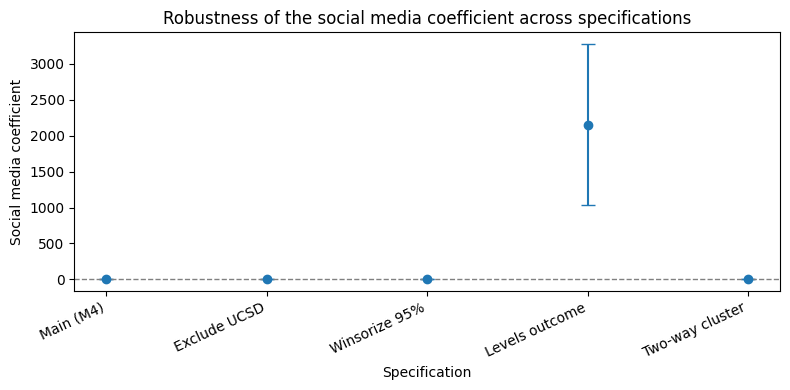

In [4]:
robustness_table

fig, ax = plt.subplots(figsize=(10, 5))
ax.errorbar(robustness_table.columns, robustness_table.loc['beta'], yerr=robustness_table.loc['se'], fmt='o', color='tab:blue', capsize=5)
ax.axhline(0, linestyle='--', color='gray', linewidth=1)
ax.set_ylabel('Social media coefficient')
ax.set_xlabel('Specification')
ax.set_title('Robustness of the social media coefficient across specifications')
ax.set_xticks(range(len(robustness_table.columns)))
ax.set_xticklabels(robustness_table.columns, rotation=25, ha='right')
plt.tight_layout()
plt.show()


## 5. Interpretation of robustness results

- **Main result:** The preferred log-linear model (M4) estimates a positive social media premium on NIL transaction values.
- **Alternative controls:** The year+school FE specification (M3) produces a similarly positive coefficient, indicating the main result is not driven only by the sport fixed effects.
- **Alternative samples:** The estimate remains positive when dropping UC San Diego and when winsorizing the outcome at the 95th percentile, so the result is not primarily driven by that school or by extreme high-value groups.
- **Alternative functional form:** The positive association survives when using raw average transaction values instead of log(1+value), although the coefficient is now measured in level units rather than percentage changes.
- **Alternative inference:** Two-way school and sport clustered standard errors are similar in magnitude to the preferred school-clustered estimates, which supports the stability of the inference.

### Summary
The surviving pattern across these checks suggests the main descriptive association is not an artifact of a single control set, sample choice, functional form, or clustering assumption. At the same time, the association remains a conditional correlation, not a causal effect, and the inference is still conservative under clustering.
